In [1]:
import pandas as pd
import numpy as np
from scipy.io import loadmat
import matplotlib.pyplot as plt
# import tensorflow as tf
import keras
from sklearn.model_selection import train_test_split

In [2]:
df = pd.read_csv("/kaggle/input/eeg-based-biometric-competition/Enrollment_Info.csv")
df.head()

,EpochID,SubjectID,Session,Task,Usage
0,epoch000001,sub001,1,10,1
1,epoch000002,sub001,1,10,1
2,epoch000003,sub001,1,11,1
3,epoch000004,sub001,1,13,1
4,epoch000005,sub001,1,5,1


In [3]:
y = []
for subid in df['SubjectID']:
    if subid == 'sub021':
        break
    y.append(subid)
y = np.array(pd.get_dummies(y))
print(y.shape, y)

(12227, 20) [[1 0 0 ... 0 0 0]
 [1 0 0 ... 0 0 0]
 [1 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 1]
 [0 0 0 ... 0 0 1]
 [0 0 0 ... 0 0 1]]


In [4]:
x = []

for epochid in df['EpochID']:
    if epochid == 'epoch012228':
        break
    print(epochid)
    annots = loadmat('/kaggle/input/eeg-based-biometric-competition/Enrollment/'+epochid+'.mat')
    wave = annots['epoch_data']
    wave = np.array(wave[:-1])
    x.append(wave.T)

epoch000001
epoch000002
epoch000003
epoch000004
epoch000005
epoch000006
epoch000007
epoch000008
epoch000009
epoch000010
epoch000011
epoch000012
epoch000013
epoch000014
epoch000015
epoch000016
epoch000017
epoch000018
epoch000019
epoch000020
epoch000021
epoch000022
epoch000023
epoch000024
epoch000025
epoch000026
epoch000027
epoch000028
epoch000029
epoch000030
epoch000031
epoch000032
epoch000033
epoch000034
epoch000035
epoch000036
epoch000037
epoch000038
epoch000039
epoch000040
epoch000041
epoch000042
epoch000043
epoch000044
epoch000045
epoch000046
epoch000047
epoch000048
epoch000049
epoch000050
epoch000051
epoch000052
epoch000053
epoch000054
epoch000055
epoch000056
epoch000057
epoch000058
epoch000059
epoch000060
epoch000061
epoch000062
epoch000063
epoch000064
epoch000065
epoch000066
epoch000067
epoch000068
epoch000069
epoch000070
epoch000071
epoch000072
epoch000073
epoch000074
epoch000075
epoch000076
epoch000077
epoch000078
epoch000079
epoch000080
epoch000081
epoch000082
epoch000083
epoc

In [5]:
x = np.array(x)
x.shape

(12227, 1000, 64)

In [6]:
print(x.shape, y.shape)

(12227, 1000, 64) (12227, 20)


In [7]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=43, stratify=y)
print(x_train.shape, x_test.shape, y_train.shape, y_test.shape)

(9781, 1000, 64) (2446, 1000, 64) (9781, 20) (2446, 20)


In [8]:
model = keras.models.Sequential()
model.add(keras.layers.LSTM(256, activation='tanh', return_sequences=True, input_shape=(1000, 64)))
model.add(keras.layers.LSTM(128, activation='tanh', return_sequences=True))
model.add(keras.layers.Dropout(0.3))
model.add(keras.layers.LSTM(128, activation='tanh', return_sequences=True))
model.add(keras.layers.Dropout(0.3))
model.add(keras.layers.LSTM(64, activation='tanh'))

model.add(keras.layers.Dense(64, activation='relu'))
model.add(keras.layers.Dense(20, activation='softmax'))

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 1000, 256)         328704    
                                                                 
 lstm_1 (LSTM)               (None, 1000, 128)         197120    
                                                                 
 dropout (Dropout)           (None, 1000, 128)         0         
                                                                 
 lstm_2 (LSTM)               (None, 1000, 128)         131584    
                                                                 
 dropout_1 (Dropout)         (None, 1000, 128)         0         
                                                                 
 lstm_3 (LSTM)               (None, 64)                49408     
                                                                 
 dense (Dense)               (None, 64)                4

In [9]:
model.compile(optimizer='rmsprop', loss='categorical_crossentropy', metrics=['accuracy'])

In [10]:
checkpoint_cb = keras.callbacks.ModelCheckpoint('LSTM_Model.h5', save_best_only=True)


In [11]:
history = model.fit(x_train, y_train, epochs=60, validation_split=0.2, callbacks = [checkpoint_cb])

Epoch 1/60
245/245 [==============================] - 99s 362ms/step - loss: 2.6757 - accuracy: 0.1832 - val_loss: 2.3413 - val_accuracy: 0.2805
Epoch 2/60
245/245 [==============================] - 91s 371ms/step - loss: 2.0578 - accuracy: 0.3654 - val_loss: 2.0420 - val_accuracy: 0.3766
Epoch 3/60
245/245 [==============================] - 91s 371ms/step - loss: 1.6878 - accuracy: 0.4747 - val_loss: 1.9130 - val_accuracy: 0.4134
Epoch 4/60
245/245 [==============================] - 87s 356ms/step - loss: 1.3924 - accuracy: 0.5611 - val_loss: 1.6765 - val_accuracy: 0.4880
Epoch 5/60
245/245 [==============================] - 87s 355ms/step - loss: 1.1694 - accuracy: 0.6238 - val_loss: 1.6927 - val_accuracy: 0.4997
Epoch 6/60
245/245 [==============================] - 91s 371ms/step - loss: 1.0236 - accuracy: 0.6699 - val_loss: 1.6873 - val_accuracy: 0.5335
Epoch 7/60
245/245 [==============================] - 91s 372ms/step - loss: 0.8807 - accuracy: 0.7101 - val_loss: 1.5516 - val_ac

In [12]:
print(model.evaluate(x_test, y_test))

77/77 [==============================] - 8s 108ms/step - loss: 0.6112 - accuracy: 0.8283
[0.6112351417541504, 0.8282910585403442]


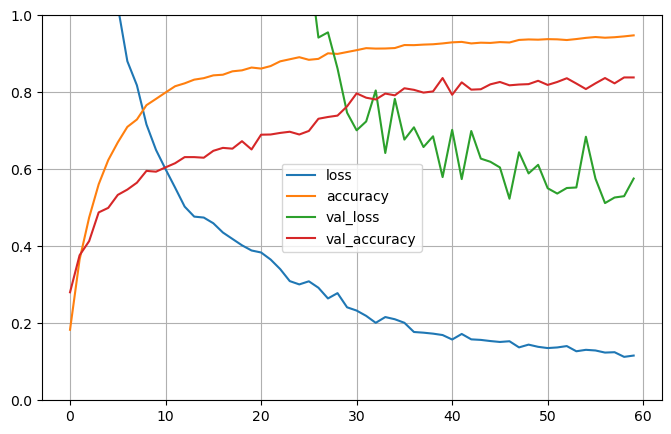

In [13]:
df_hist = pd.DataFrame(history.history)
pd.DataFrame(history.history).plot(figsize = (8,5))
df_hist.to_csv('History1_LSTM.csv')
plt.grid(True)
plt.gca().set_ylim(0,1)
plt.savefig("LSTM_graph.png")
plt.show()